In [2]:
%load_ext autoreload
%autoreload 2
import os, sys, re
import numpy as np
import pandas as pd
import scanpy as sc
import torch
import time
import PINN

os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

In [3]:
from torchcfm.conditional_flow_matching import *
from torchdyn.core import NeuralODE
from torchcfm.utils import plot_trajectories, torch_wrapper

In [4]:
from torchdiffeq import odeint
from torchcfm.optimal_transport import wasserstein

In [5]:
import matplotlib.pyplot as plt
from matplotlib import cm

In [6]:
device = 'cuda:3'

In [7]:
adata = sc.read_h5ad(f"data/klein_subset.h5ad")
cellstate_key = "DM_EigenVectors_multiscaled"
n_dimension = 5
base_cellstate = adata.obsm[cellstate_key][:,:n_dimension].copy()

In [8]:
coords = adata.obsm[cellstate_key]
coords = (coords - coords.mean(axis=0)) / coords.std(axis=0)
adata.obsm[f"{cellstate_key}_standardized"] = coords

In [9]:
timepoint_key = 'timepoint_tx_days'

In [10]:
test_clones = ['Clone_3869' , 'Clone_2673' , 'Clone_2831']
cbs = [adata.obs.query("`timepoint_tx_days` == @t & `clones` in @test_clones").index.to_list()
            for t in adata.uns['pop']['t']]
overlapped_cb_indexs = [[np.where(adata.obs_names == cb)[0] for cb in cb_t] for cb_t in cbs]

In [59]:
overlapped_cb_indexs = [[np.where(adata.obs_names == cb)[0] for cb in cb_t] for cb_t in cbs]

# start simulation

In [17]:
test_X = [adata[cb].obsm[cellstate_key][:,:n_dimension].copy() for cb in cbs]

for X in test_X:
    print(X.shape)

(4, 5)
(65, 5)
(187, 5)


In [54]:
test_ad =  adata[adata.obs.query("`clones` in @test_clones").index]

In [58]:
snap_shot = {}
for t in test_ad.obs['Time_point'].unique():
    test_ad_t = test_ad[test_ad.obs['Time_point'] == t]
    snap_shot[t] = test_ad_t.obsm[cellstate_key].copy()

In [221]:
cellstate_key = "DM_EigenVectors_multiscaled"

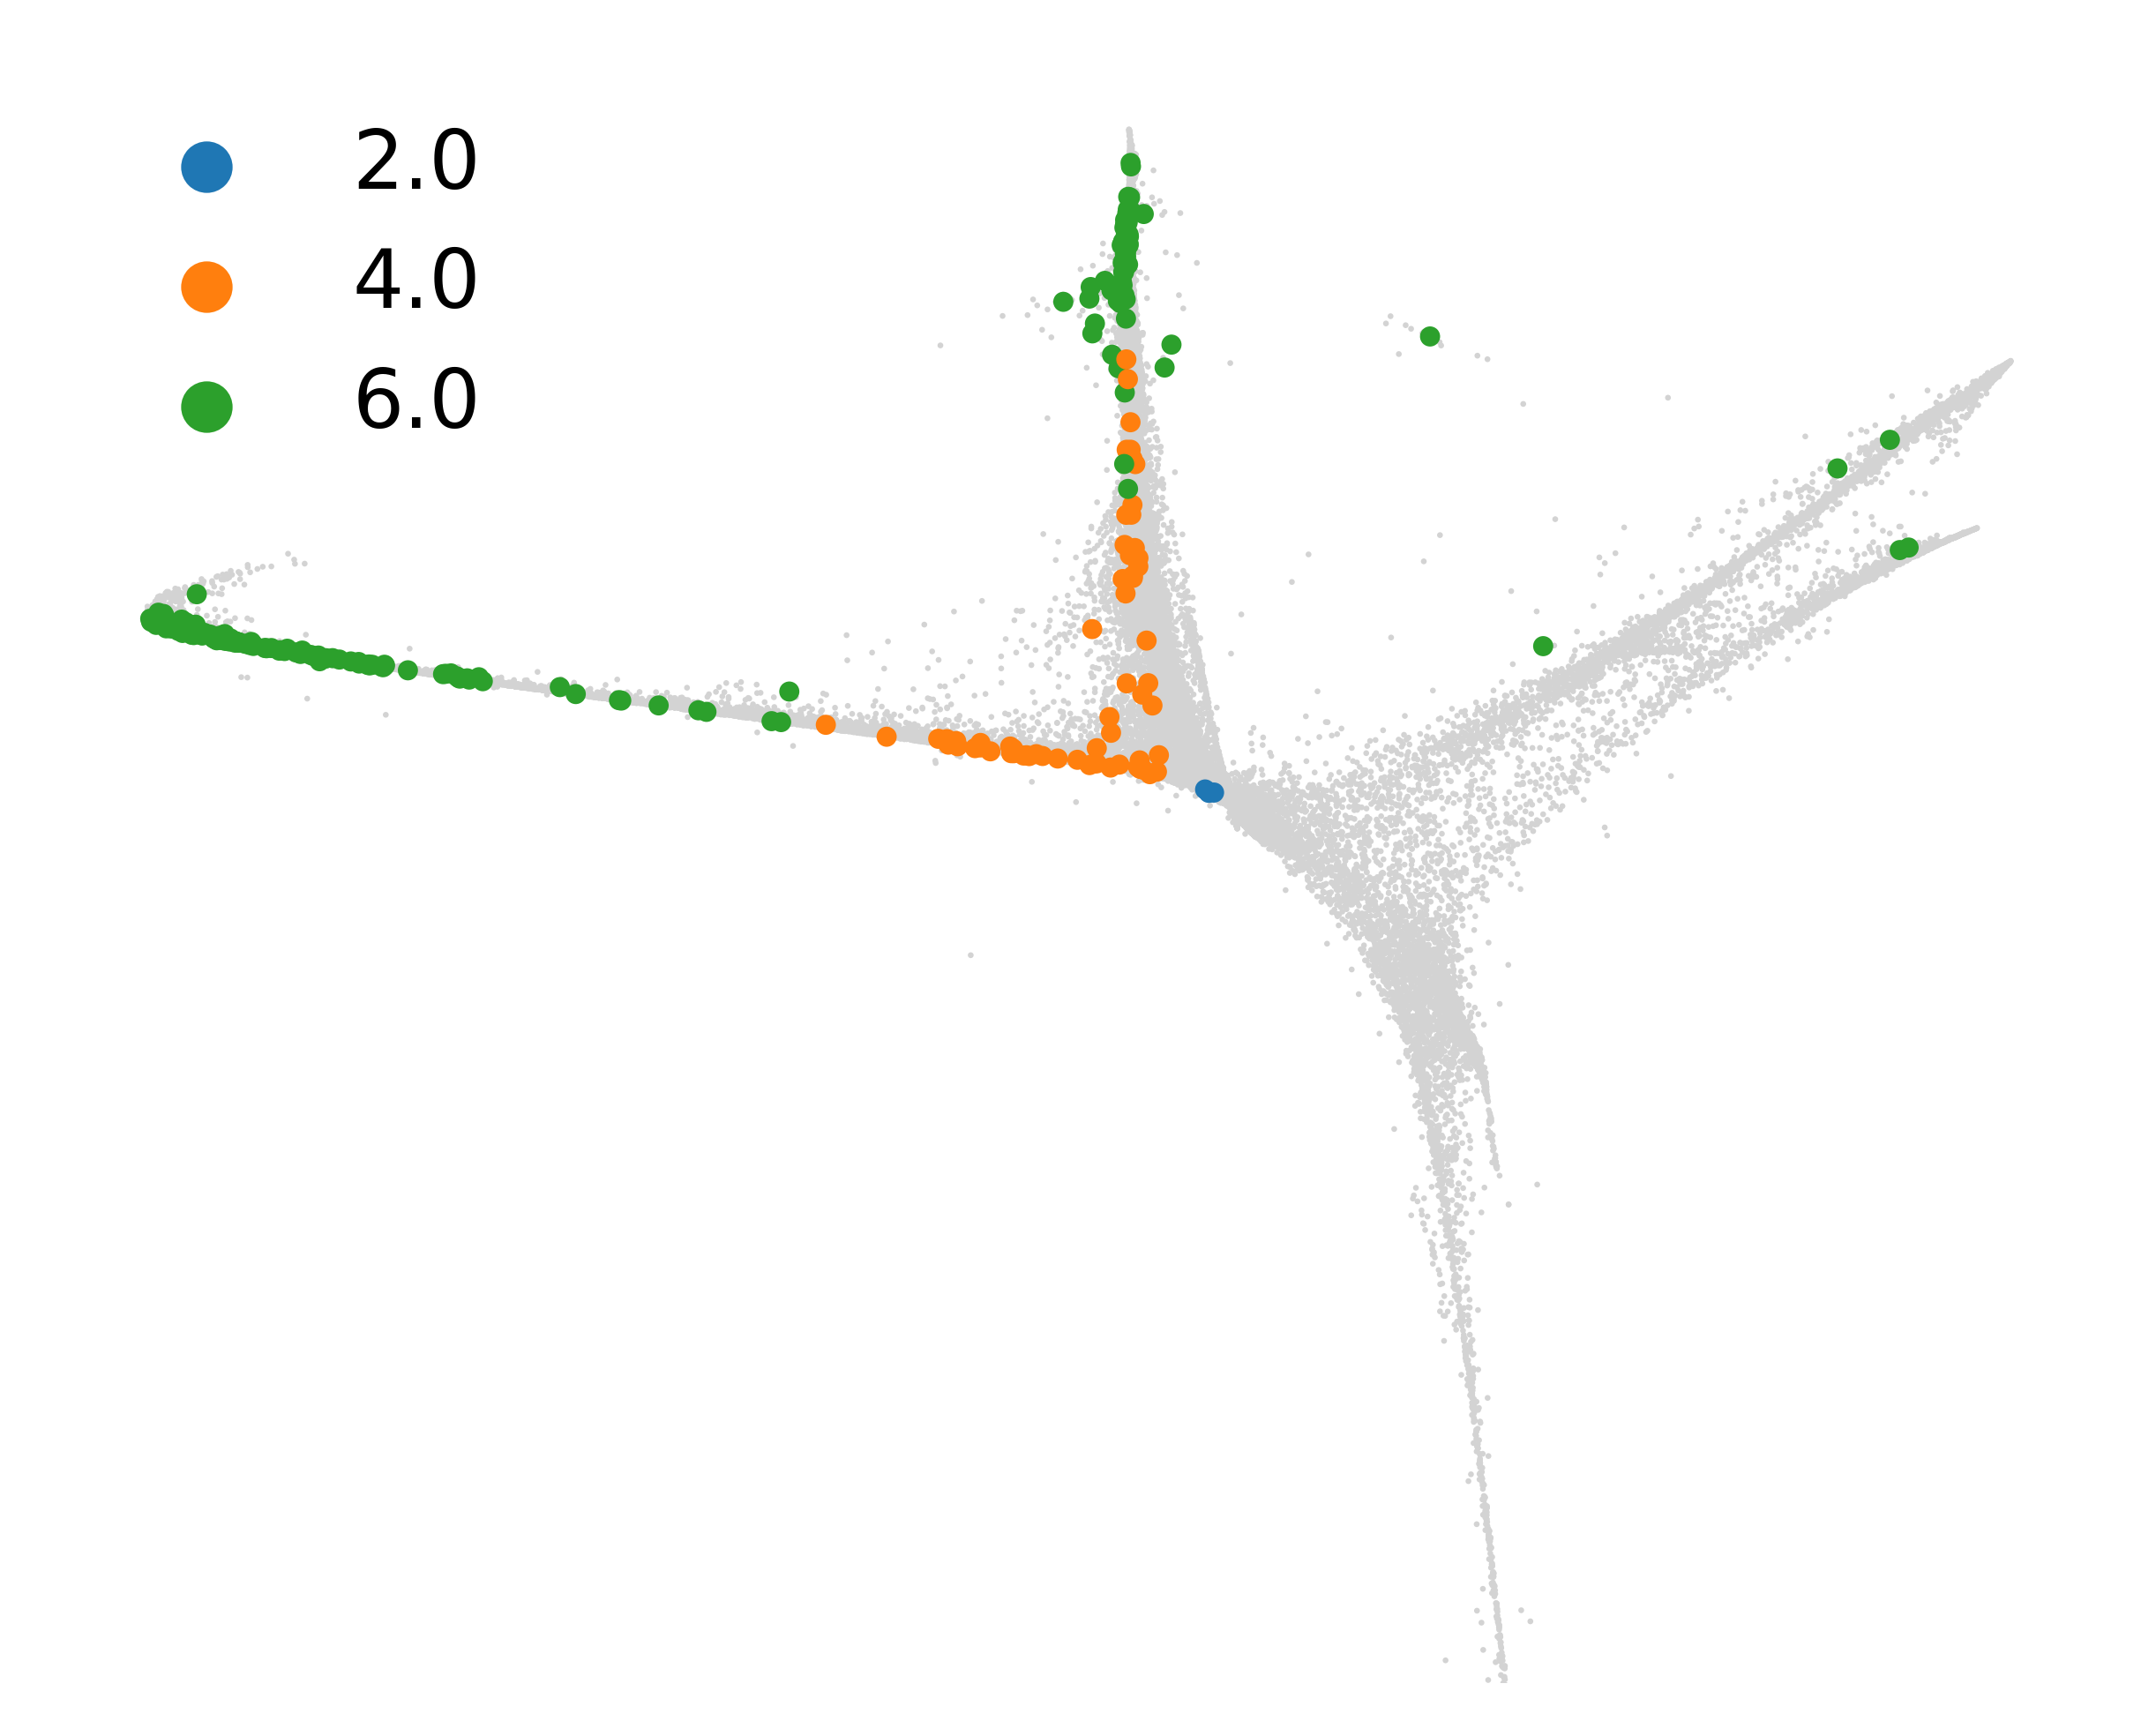

In [ ]:
fig, ax = plt.subplots(figsize=(5,4), dpi=600, frameon=False)
sc.pl.embedding( 
    adata, basis=cellstate_key,  dimensions=[0,2], ax=ax, show=False,
     frameon=False, size=30, 
)
sc.pl.embedding( 
    adata[adata.obs.query("`clones` in @test_clones").index],
    color='Time_point', size=30, frameon=False,
    basis=cellstate_key,  dimensions=[0,2], ax=ax, show=False
)

ax.set_ylim(-3.4, 2.2)
ax.set_title('')
ax.legend(fontsize=11, frameon=False)

In [21]:
adata.obsm[cellstate_key][:,2].max(), adata.obsm[cellstate_key][:,2].min()

(1.9373026, -7.9128222)

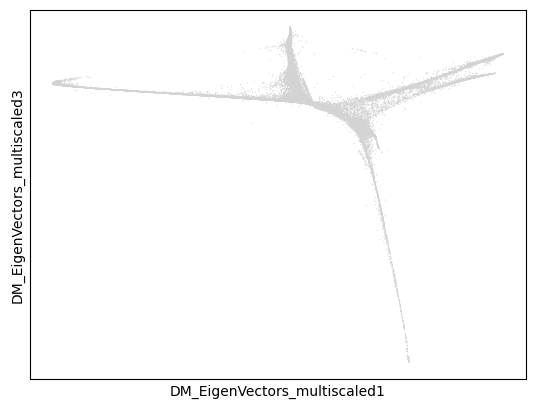

In [20]:
sc.pl.embedding( 
    adata, basis=cellstate_key,  dimensions=[0,2]
)

In [ ]:
fig, ax= plt.subplots(figsize=(6,6), dpi=600, frameon=False)
sc.pl.embedding( 
    adata, basis=cellstate_key,  dimensions=[0,2], ax=ax, show=False, return_fig=False
)
sc.pl.embedding( 
    adata[adata.obs.query("`clones` in @test_clones").index], color=['Time_point'],
    ax=ax, show=False, return_fig=False
)

TypeError: embedding() missing 1 required positional argument: 'basis'

In [92]:
colors = cm.viridis([0.1, 0.5,0.9])
popt = list(snap_shot.keys())
palette = dict(zip(popt, colors))

In [18]:
def plot_simple_traj(traj, which_dim=[0,1]):    
    n = 2000
    fig = plt.figure(figsize=(6, 6))
    ax = plt.gca()
    ax.scatter(traj[0, :n, which_dim[0]], traj[0, :n, which_dim[1]], s=13, alpha=0.8, c="black", label=r"$p_0$")
    ax.scatter(traj[:, :n, which_dim[0]], traj[:, :n, which_dim[1]], s=0.2, alpha=0.2, c="olive", label=r"$p_t$")
    ax.scatter(traj[-1, :n, which_dim[0]], traj[-1, :n, which_dim[1]], s=6, alpha=1, c="blue", label= r"$p_1$")
    plt.xticks([])
    plt.yticks([])
    return fig, ax

def plot_allcells_and_trajectories(traj, highlight_idx=range(15), which_dim=[0,1]):
    """Plot trajectories of some selected samples."""

    n = 2000
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.scatter(
        adata.obsm[cellstate_key][:, which_dim[0]],
        adata.obsm[cellstate_key][:, which_dim[1]],
        c=adata.obs[timepoint_key], s=0.4, alpha=0.1,
    )

    ax.scatter(traj[:, :n, which_dim[0]], traj[:, :n, which_dim[1]], s=0.4, alpha=0.1, c="olive", label= r"$p_1$")

    for i in highlight_idx:
        ax.plot(traj[:, i, which_dim[0]], traj[:, i, which_dim[1]], alpha=0.5, c="red" #, label=r"$X_t \mid X_0$"
                )

    return fig, ax

import seaborn as sns
def Deepseak_plot(init_cells, trajs, true_snapshots):

    trajs = np.transpose(trajs, (1,0,2)) # time, cell, dimension

    n_cells = trajs.shape[0]
    # Plotting
    plt.figure(figsize=(6, 6))

    # Plot simulated trajectories
    for i in range(n_cells):
        plt.plot(trajs[i, :, 0], trajs[i, :, 1], 'b-', alpha=0.3, label='Simulated' if i == 0 else "")

    # Plot ground-truth snapshots with KDE contours
    for timepoint, snapshot in true_snapshots.items():
        sns.kdeplot(x=snapshot[:, 0], y=snapshot[:, 1], levels=5, color='r', alpha=0.5, label=f'Ground Truth at T{timepoint}' if timepoint == 0 else "")

    # Plot initial cells
    plt.scatter(init_cells[:, 0], init_cells[:, 1], c='k', label='Initial Cells')

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Comparison of Simulated Trajectories and Ground-Truth Snapshots')
    plt.legend()
    plt.show()

from matplotlib import cm


colors = cm.viridis([0, 0.5, 1])
popt = ['2','4','6']
palette = dict(zip(popt, colors))

def plot_trajectories(snap_shot, traj, pred, which_dim=(0,1), density_levels=0.1,dpi=60):
    """
    Plot ground truth snapshots, predicted cells, and simulated trajectories.

    Parameters:
    - snap_shot: dict with time as key and coordinates ndarray as values (Ground Truth).
    - traj: ndarray of shape [n_simulate_time, n_cell, dimension] (Trajectory).
    - pred: dict with time as key and coordinates ndarray as values (Predicted cells).
    """
    fig = plt.figure(figsize=(5,4), dpi=dpi)
    ax = fig.gca()

    # Plot simulated trajectories
    n_cells = traj.shape[1]

    for i in range(n_cells):
        ax.plot(traj[:, i, which_dim[0]], traj[:, i, which_dim[1]], 'b-', color='gray', alpha=0.2, label='Simulated Trajectory' if i == 0 else "")

    t0,t1 = pred.keys()

    # Plot ground truth snapshots
    # for time, coords in snap_shot.items():
    #     plt.scatter(coords[:, which_dim[0]], coords[:, which_dim[1]], edgecolors='black', s=60, alpha=0.05, marker='^')
    
    ax.scatter(snap_shot[t1][:, which_dim[0]], snap_shot[t1][:, which_dim[1]], color=palette[t1], alpha=0.1, marker='^', s=40, label=f'Ground Truth at T{t1}')

    sns.kdeplot(x=snap_shot[t1][:, which_dim[0]], y=snap_shot[t1][:, which_dim[1]], levels=density_levels, bw_method=0.1, 
                color='black', alpha=0.1, label=f'Ground Truth Desity', ax=ax)

    # Plot predicted cells

    

    ax.scatter(pred[t1][:, which_dim[0]], pred[t1][:, which_dim[1]], color='black', s=60,  alpha=0.4)
        
    ax.scatter(pred[t0][:, which_dim[0]], pred[t0][:, which_dim[1]], color=palette[t0], s=40, alpha=0.7, label=f'Starting cells at Day{t1}')
    ax.scatter(pred[t1][:, which_dim[0]], pred[t1][:, which_dim[1]], color=palette[t1], s=40, alpha=0.7, label=f'Predicted cells at Day{t1}')

    plt.xlabel('Diffusion map 1')
    plt.ylabel('Diffusion map 2')
    # plt.title('Comparison of Ground Truth, Predicted, and Simulated Trajectories')
    plt.legend()

    sns.despine(ax=ax)

    return fig, ax

# Example usage
# snap_shot = {0: np.random.rand(10, 2), 50: np.random.rand(10, 2), 99: np.random.rand(10, 2)}
# traj = np.random.rand(100, 10, 2)
# pred = {0: np.random.rand(10, 2), 50: np.random.rand(10, 2), 99: np.random.rand(10, 2)}
# plot_trajectories(snap_shot, traj, pred)

# PINN v

In [19]:
ckpt_path = "logs/klein_subset-DM_EigenVectors_multiscaled_n3/pde_params_tsense/lightning_logs/version_4/checkpoints/epoch=20-total_loss=0.21981135.ckpt"

model_name = ckpt_path.split("/")[2].replace("_tsense","")
model_class = eval(f"PINN.models.{model_name}")

cellstate_key = ckpt_path.split("/")[1].split("-")[1].split("_n")[0]
n_timepoint = int(ckpt_path.split("/")[1].split("-")[1].split("_n")[1])

# MODEL CLASS and define model
pde_model = model_class.load_from_checkpoint(ckpt_path)
device = pde_model.device

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/pytorch_lightning/utilities/migration/utils.py:49: PossibleUserWarning: The loaded checkpoint was produced with Lightning v2.3.0, which is newer than your current Lightning version: v1.9.5
  rank_zero_warn(


In [20]:
cellstate_key = ckpt_path.split("/")[1].split("-")[1].split("_n")[0]
n_timepoint = int(ckpt_path.split("/")[1].split("-")[1].split("_n")[1])

In [21]:
def v_ode(t, state):
    s_in = state
    t_in = torch.full((s_in.shape[0],), t.item()).float().to(s_in.device)
    # dsdt
    return pde_model.v(s_in, t_in) 

In [22]:
adata.uns['pop']['t'] 

array([2, 4, 6])

In [23]:
popt = adata.uns['pop']['t'] 
t_list = popt / popt[0]

starting_i = 1
snap_shot = {str(popt[starting_i]): test_X[starting_i]}
pred = {str(popt[starting_i]): test_X[starting_i]}
trajs = []

starting_i =1

t0 = t_list[starting_i]
t1 = t_list[starting_i+1]
s_in = torch.tensor(test_X[starting_i]).to(device).float()

with torch.no_grad():
    s_t = odeint(v_ode, 
                y0 = s_in, 
                t = torch.linspace(t0, t1, 11),
                atol = 1e-8,
                rtol = 1e-8,
                method = 'dopri5')
    traj = s_t.detach().cpu()#.numpy()

trajs.append(traj)

snap_shot[str(popt[starting_i+1])] = test_X[starting_i+1]
pred[str(popt[starting_i+1])] = traj[-1]

trajs = np.concatenate(trajs, axis=1)

print("W2: \t", wasserstein(traj[-1], torch.tensor(test_X[starting_i+1]), power=2, method='exact'))
print("W2 skh reg=0.01: \t", wasserstein(traj[-1], torch.tensor(test_X[starting_i+1]), power=2, method='sinkhorn', reg=0.05))
print("W2 skh reg=0.05: \t", wasserstein(traj[-1], torch.tensor(test_X[starting_i+1]), power=2, method='sinkhorn', reg=0.5))
print("W2 skh reg=1: \t", wasserstein(traj[-1], torch.tensor(test_X[starting_i+1]), power=2, method='sinkhorn', reg=5))

W2: 	 2.144477555413408
W2 skh reg=0.01: 	 0.021005078267516433
W2 skh reg=0.05: 	 2.1876413508056696
W2 skh reg=1: 	 2.4392205863022047


/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/ot/bregman/_sinkhorn.py:498: RuntimeWarning: divide by zero encountered in divide
  v = b / KtransposeU
/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/ot/bregman/_sinkhorn.py:506: UserWarning: Warning: numerical errors at iteration 0
  warnings.warn('Warning: numerical errors at iteration %d' % ii)


In [24]:
snap_shot.keys()

dict_keys(['4', '6'])

/tmp/ipykernel_3144408/1511499025.py:80: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  ax.plot(traj[:, i, which_dim[0]], traj[:, i, which_dim[1]], 'b-', color='gray', alpha=0.2, label='Simulated Trajectory' if i == 0 else "")


[]

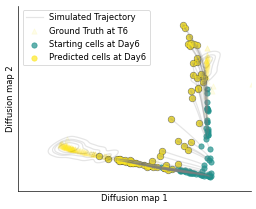

In [25]:
fig, ax = plot_trajectories(snap_shot, trajs, pred, 
            which_dim=[0,2], 
            density_levels=[0.2,0.4,0.6,0.8, 1],
            dpi=60
            )
ax.set_ylim(-0.5,2.5)
ax.set_xlim(-5.5,1)
ax.set_xticks([])
ax.set_yticks([])

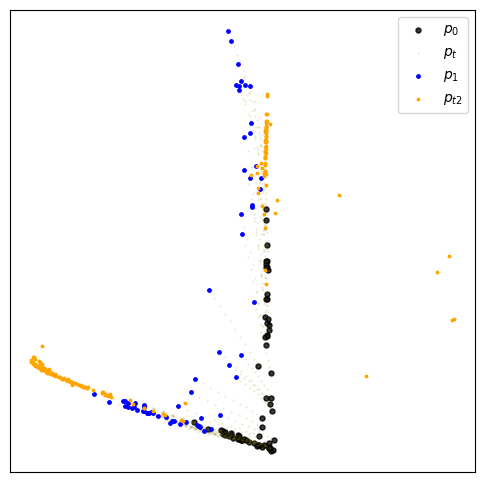

In [53]:
which_dim = [0,2]
fig, ax = plot_simple_traj(traj.numpy(), which_dim=which_dim)
# ax.scatter(test_X[0][:,0], test_X[0][:,1], s=6, label=r'$p_{t0}$')
# ax.scatter(test_X[1][:,0], test_X[1][:,1], s=6, label=r'$p_{t1}$')
ax.scatter(test_X[2][:,which_dim[0]], test_X[2][:,which_dim[1]], s=3, label=r'$p_{t2}$', c='orange')
plt.legend()
fig.show()

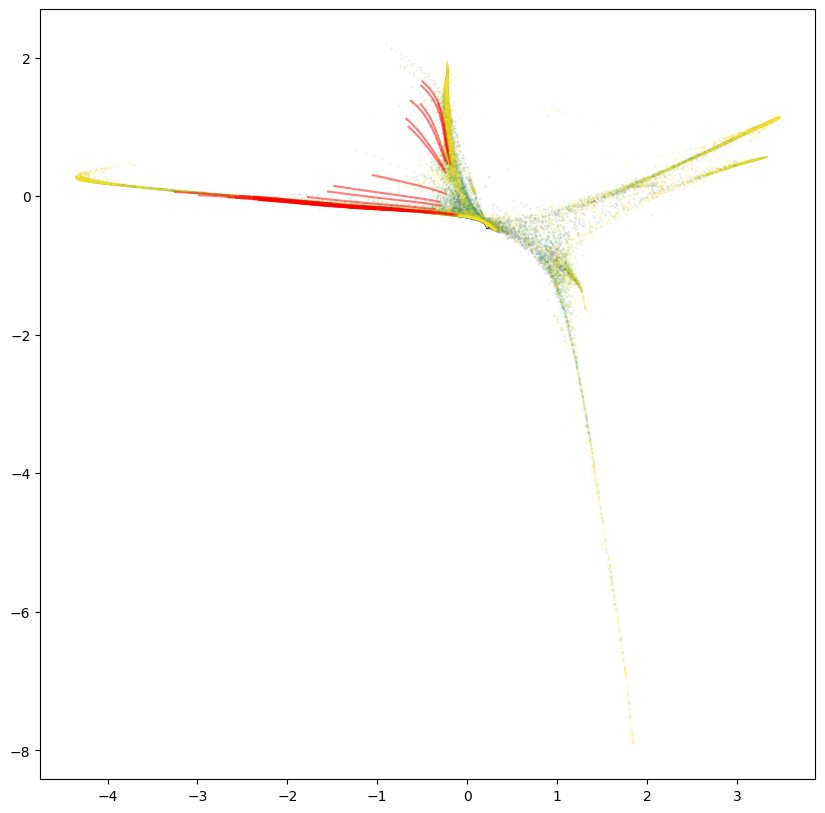

In [93]:
which_dim = [0,2]

w_idx = np.arange(traj.shape[1])
distance_by_i = np.array([wasserstein(traj[-1][[i]], torch.tensor(test_X[starting_i+1]), power=2, method='exact') for i in w_idx])
sorted_idx = [x for _, x in sorted(zip(distance_by_i, w_idx))]

fig, ax = plot_allcells_and_trajectories(traj.cpu().numpy(),
                                highlight_idx=range(30),
                            which_dim=which_dim)
fig.show()

# load TIGON model

In [51]:
# git clone TIGON 
sys.path.append('/ssd/users/Wergillius/Project/TIGON')
import utility

In [ ]:
timepoints = [0.5, 1.0, 1.5]

In [10]:
ckpt = torch.load("logs/TIGON/model2/ckpt.pth")

In [12]:
LOSS = ckpt['LOSS']
Trans = ckpt['TRANS']
L2_1 = ckpt['L2_1']
L2_2 = ckpt['L2_2']
Sigma = ckpt['Sigma']

In [16]:
LOSS[80],LOSS[100]

(0.5170110464096069, 8.993673324584961)

In [18]:
best_checkpoint = torch.load("logs/TIGON/model2/ckpt_itr80.pth")
model_state_dict = best_checkpoint['func_state_dict']

In [ ]:
device = 'cuda:3'

func = utility.UOT(in_out_dim=n_dimension, 
           hidden_dim=16, n_hiddens=4, activation='Tanh').to(device)
func.load_state_dict(model_state_dict)

v = func.hyper_net1.to(device)
g = func.hyper_net2.to(device)

In [43]:
torch.from_numpy(test_X[0]).float().to(device).shape

torch.Size([4, 5])

In [54]:
node = NeuralODE(v, solver="dopri5", sensitivity="adjoint")

In [ ]:
with torch.no_grad():
    traj_0_1 = odeint(v,  y0 = torch.from_numpy(test_X[0]).float().to(device), 
              t = torch.linspace(0.5, 1.0, 2), method='dopri5'
              ).cpu()


wasserstein(traj_0_1[-1], torch.tensor(test_X[1]), power=2)

1.115632052657166

In [212]:
with torch.no_grad():
    traj_1_2 = odeint(v,  y0 = torch.from_numpy(test_X[1]).float().to(device), 
              t = torch.linspace(1, 1.5, 200), method='dopri5'
              ).cpu()

print("W2: \t", wasserstein(traj_1_2[-1], torch.tensor(test_X[2]), power=2, method='exact'))
print("W2 skh reg=0.01: \t", wasserstein(traj_1_2[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=0.05))
print("W2 skh reg=0.05: \t", wasserstein(traj_1_2[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=0.5))
print("W2 skh reg=1: \t", wasserstein(traj_1_2[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=5))

W2: 	 3.457949849823799
W2 skh reg=0.01: 	 0.01159203084823636
W2 skh reg=0.05: 	 3.4819759527116725
W2 skh reg=1: 	 3.6565807834299573


In [222]:
with torch.no_grad():
    traj_1_2 = odeint(v,  y0 = torch.from_numpy(test_X[1]).float().to(device), 
              t = torch.linspace(4.0, 6.0, 200), method='dopri5'
              ).cpu()

print("W2: \t", wasserstein(traj_1_2[-1], torch.tensor(test_X[2]), power=2, method='exact'))
print("W2 skh reg=0.01: \t", wasserstein(traj_1_2[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=0.05))
print("W2 skh reg=0.05: \t", wasserstein(traj_1_2[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=0.5))
print("W2 skh reg=1: \t", wasserstein(traj_1_2[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=5))

W2: 	 3.493203880399981
W2 skh reg=0.01: 	 0.001563985608908302
W2 skh reg=0.05: 	 3.516798497486617
W2 skh reg=1: 	 3.689562078316061


In [ ]:
wasserstein

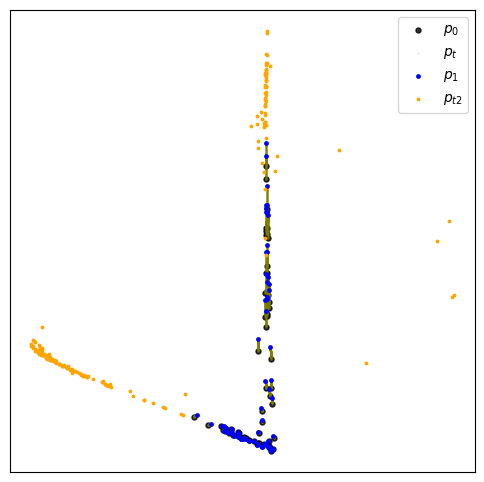

In [193]:
which_dim = [0,2]
fig, ax = plot_simple_traj(traj_1_2.cpu().numpy(), which_dim=which_dim)
# ax.scatter(test_X[0][:,0], test_X[0][:,1], s=6, label=r'$p_{t0}$')
# ax.scatter(test_X[1][:,0], test_X[1][:,1], s=6, label=r'$p_{t1}$')
ax.scatter(test_X[2][:,which_dim[0]], test_X[2][:,which_dim[1]], s=3, label=r'$p_{t2}$', c='orange')
plt.legend()
fig.show()

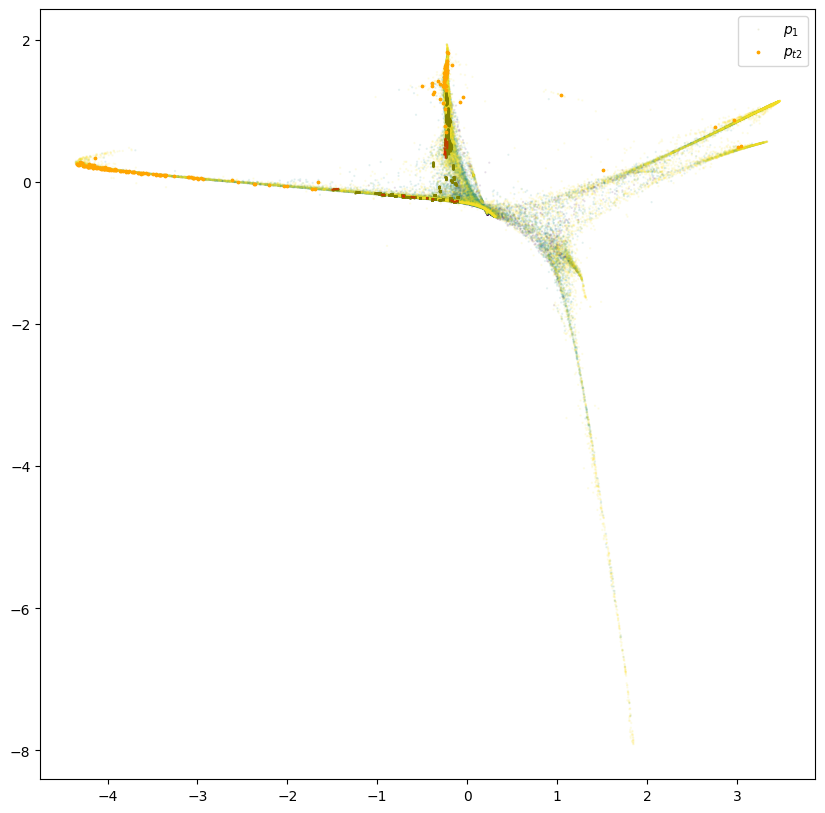

In [194]:
which_dim = [0,2]
fig, ax = plot_allcells_and_trajectories(traj_1_2.cpu().numpy(), which_dim=which_dim)
# ax.scatter(test_X[0][:,0], test_X[0][:,1], s=6, label=r'$p_{t0}$')
# ax.scatter(test_X[1][:,0], test_X[1][:,1], s=6, label=r'$p_{t1}$')
ax.scatter(test_X[2][:,which_dim[0]], test_X[2][:,which_dim[1]], s=3, label=r'$p_{t2}$', c='orange')
plt.legend()
fig.show()

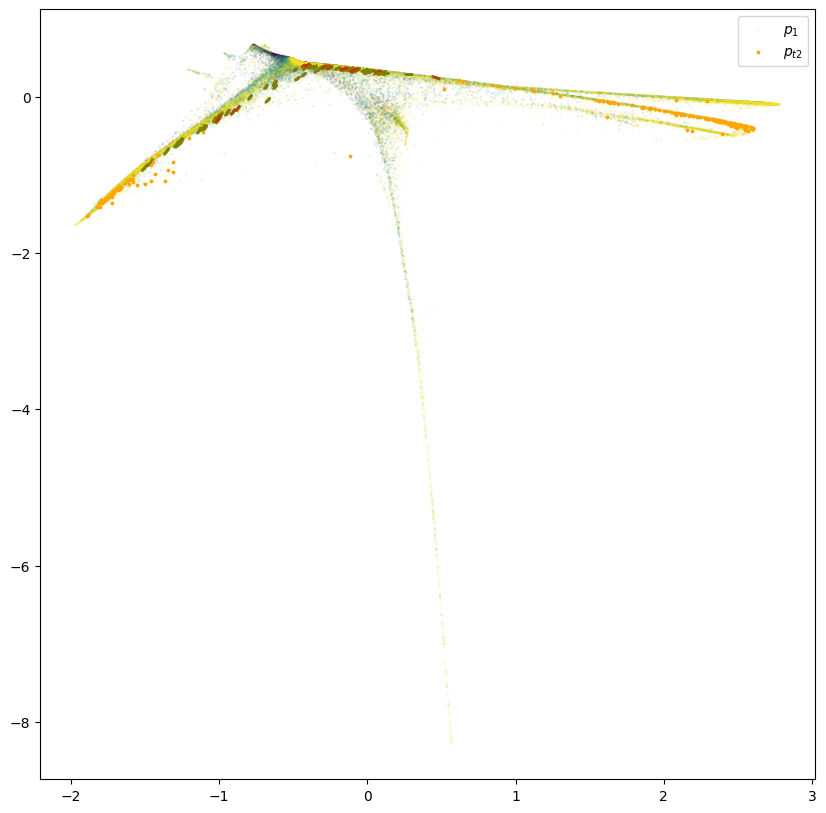

In [195]:
which_dim = [1,3]
fig, ax = plot_trajectories(traj_1_2.cpu().numpy(), which_dim=which_dim)
# ax.scatter(test_X[0][:,0], test_X[0][:,1], s=6, label=r'$p_{t0}$')
# ax.scatter(test_X[1][:,0], test_X[1][:,1], s=6, label=r'$p_{t1}$')
ax.scatter(test_X[2][:,which_dim[0]], test_X[2][:,which_dim[1]], s=3, label=r'$p_{t2}$', c='orange')
plt.legend()
fig.show()

# OT_cfm model

In [217]:
savedir = "logs/CFM"
checkpoint = torch.load(f"{savedir}/Weinreb_{cellstate_key}_ot_cfm_.pt")
ot_cfm_model = checkpoint['model'].to(device)

In [218]:
node = NeuralODE(torch_wrapper(ot_cfm_model), solver="dopri5", sensitivity="adjoint")
with torch.no_grad():
    traj = node.trajectory(
        torch.from_numpy(test_X[1]).float().to(device),
        t_span=torch.linspace(1, 2, 200),
    ).cpu()

print("W2: \t", wasserstein(traj[-1], torch.tensor(test_X[2]), power=2, method='exact'))
print("W2 skh reg=0.01: \t", wasserstein(traj[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=0.05))
print("W2 skh reg=0.05: \t", wasserstein(traj[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=0.5))
print("W2 skh reg=1: \t", wasserstein(traj[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=5))

W2: 	 3.069594847945499
W2 skh reg=0.01: 	 0.022653652218989042
W2 skh reg=0.05: 	 3.098471623118887
W2 skh reg=1: 	 3.2898329654586917


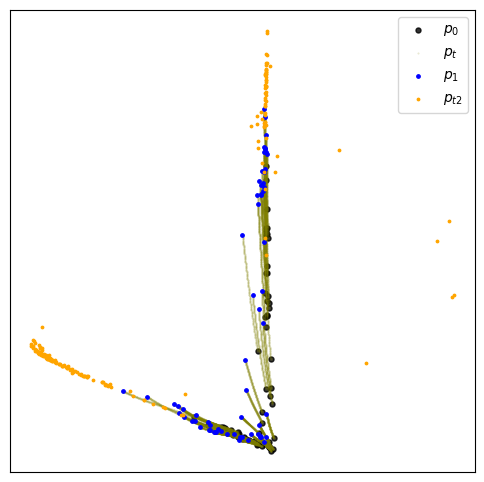

In [189]:
which_dim = [0,2]
fig, ax = plot_simple_traj(traj.cpu().numpy(), which_dim=which_dim)
# ax.scatter(test_X[0][:,0], test_X[0][:,1], s=6, label=r'$p_{t0}$')
# ax.scatter(test_X[1][:,0], test_X[1][:,1], s=6, label=r'$p_{t1}$')
ax.scatter(test_X[2][:,which_dim[0]], test_X[2][:,which_dim[1]], s=3, label=r'$p_{t2}$', c='orange')
plt.legend()
fig.show()

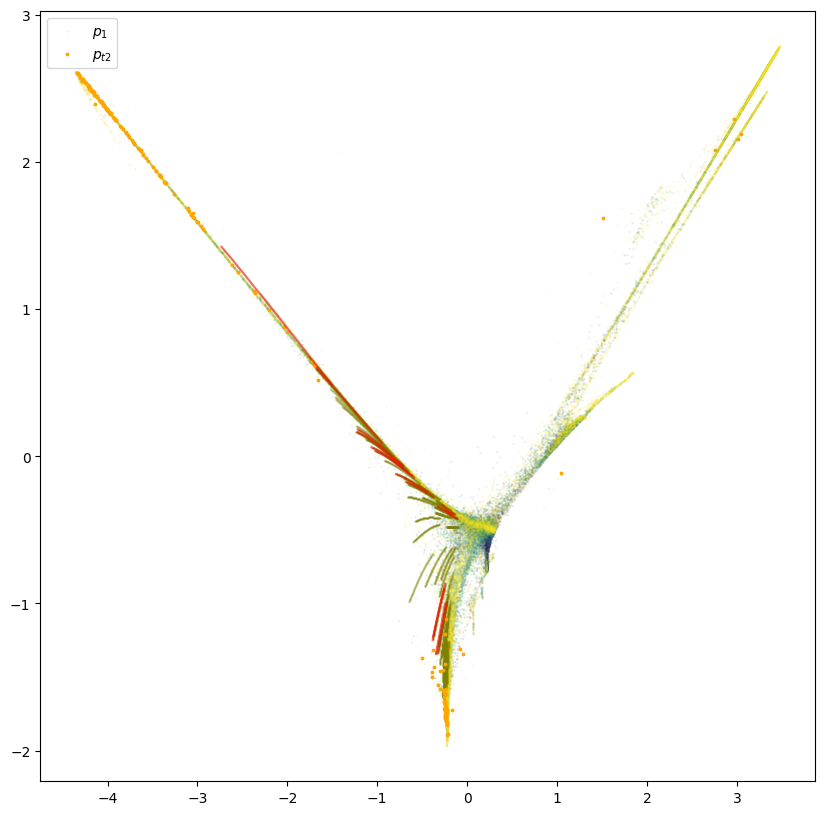

In [190]:
which_dim = [0,1]
fig, ax = plot_trajectories(traj.cpu().numpy(), which_dim=which_dim)
# ax.scatter(test_X[0][:,0], test_X[0][:,1], s=6, label=r'$p_{t0}$')
# ax.scatter(test_X[1][:,0], test_X[1][:,1], s=6, label=r'$p_{t1}$')
ax.scatter(test_X[2][:,which_dim[0]], test_X[2][:,which_dim[1]], s=3, label=r'$p_{t2}$', c='orange')
plt.legend()
fig.show()

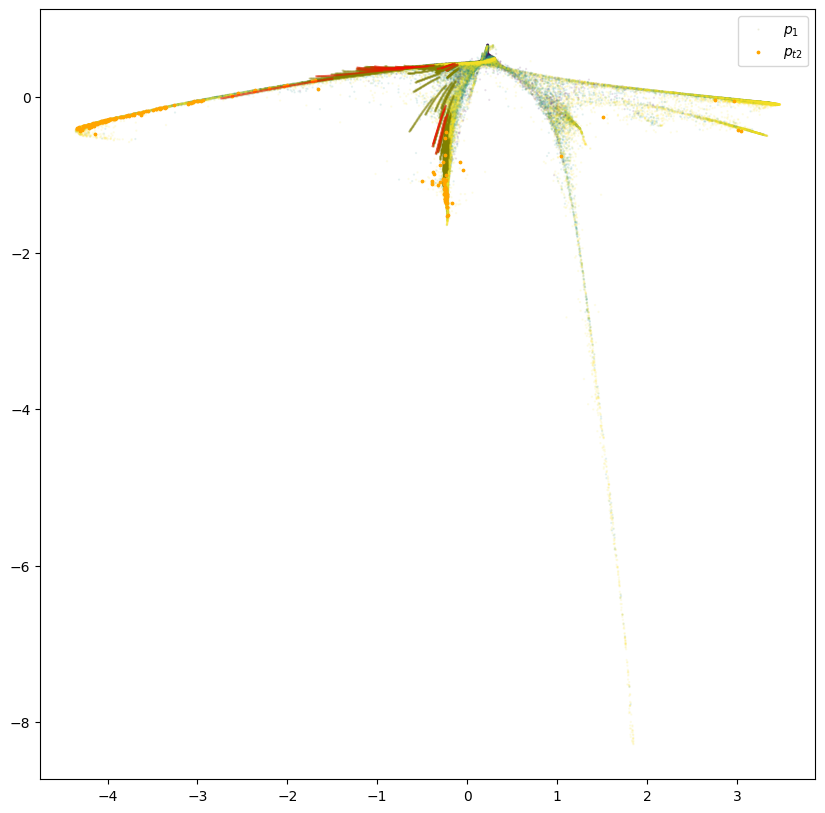

In [191]:
which_dim = [0,3]
fig, ax = plot_trajectories(traj.cpu().numpy(), which_dim=which_dim)
# ax.scatter(test_X[0][:,0], test_X[0][:,1], s=6, label=r'$p_{t0}$')
# ax.scatter(test_X[1][:,0], test_X[1][:,1], s=6, label=r'$p_{t1}$')
ax.scatter(test_X[2][:,which_dim[0]], test_X[2][:,which_dim[1]], s=3, label=r'$p_{t2}$', c='orange')
plt.legend()
fig.show()

In [104]:
wasserstein(traj[-1], torch.tensor(test_X[1]), power=2)

1.2256528716729667

# SF2M

In [220]:
savedir = "logs/CFM"
checkpoint = torch.load(f"{savedir}/Weinreb_{cellstate_key}_sf2m_sigma_0.25.pt")
sf2m_model = checkpoint['model'].to(device)

In [221]:
node = NeuralODE(torch_wrapper(sf2m_model), solver="dopri5", sensitivity="adjoint")
with torch.no_grad():
    traj = node.trajectory(
        torch.from_numpy(test_X[1]).float().to(device),
        t_span=torch.linspace(1, 2, 200),
    ).cpu()

print("W2: \t", wasserstein(traj[-1], torch.tensor(test_X[2]), power=2, method='exact'))
print("W2 skh reg=0.01: \t", wasserstein(traj[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=0.05))
print("W2 skh reg=0.05: \t", wasserstein(traj[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=0.5))
print("W2 skh reg=1: \t", wasserstein(traj[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=5))

W2: 	 2.997398643204862
W2 skh reg=0.01: 	 0.02189552092846346
W2 skh reg=0.05: 	 3.026866327282345
W2 skh reg=1: 	 3.224602721316507


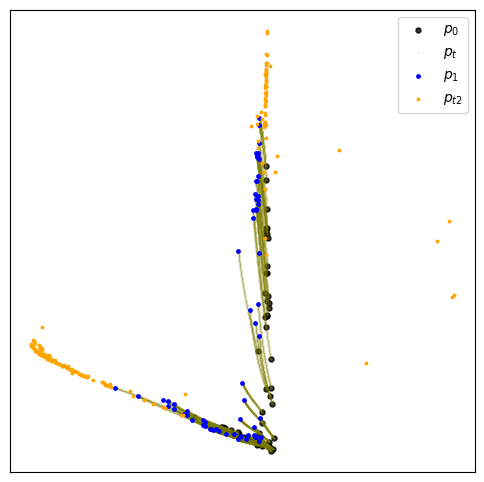

In [199]:
which_dim = [0,2]
fig, ax = plot_simple_traj(traj.cpu().numpy(), which_dim=which_dim)
# ax.scatter(test_X[0][:,0], test_X[0][:,1], s=6, label=r'$p_{t0}$')
# ax.scatter(test_X[1][:,0], test_X[1][:,1], s=6, label=r'$p_{t1}$')
ax.scatter(test_X[2][:,which_dim[0]], test_X[2][:,which_dim[1]], s=3, label=r'$p_{t2}$', c='orange')
plt.legend()
fig.show()

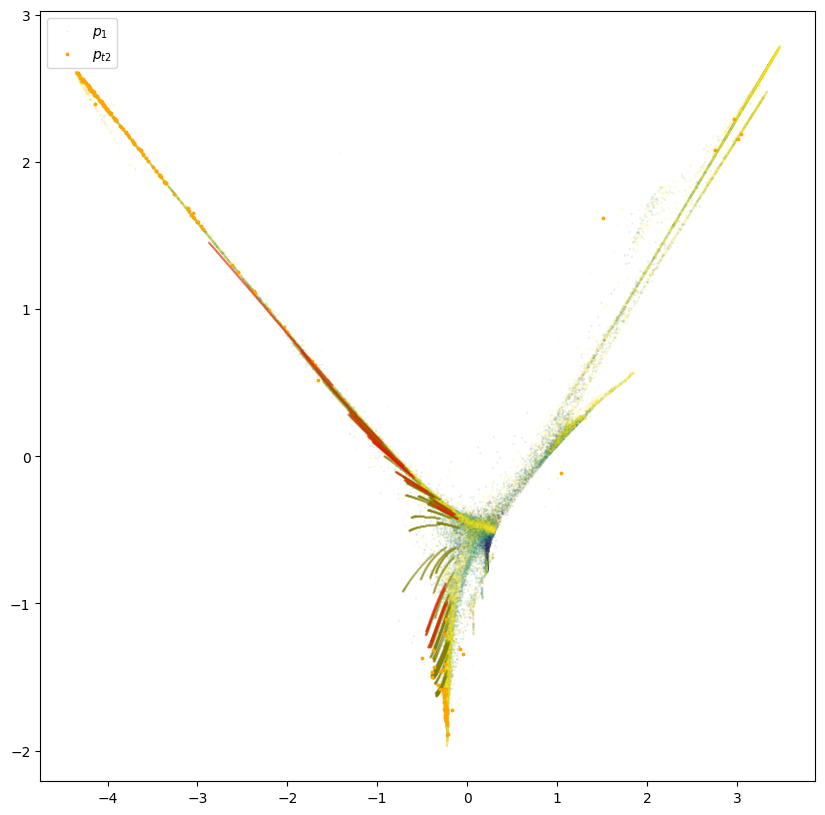

In [203]:
which_dim = [0,1]
fig, ax = plot_trajectories(traj.cpu().numpy(), which_dim=which_dim)
# ax.scatter(test_X[0][:,0], test_X[0][:,1], s=6, label=r'$p_{t0}$')
# ax.scatter(test_X[1][:,0], test_X[1][:,1], s=6, label=r'$p_{t1}$')
ax.scatter(test_X[2][:,which_dim[0]], test_X[2][:,which_dim[1]], s=3, label=r'$p_{t2}$', c='orange')
plt.legend()
fig.show()

# PINN

In [65]:
import functools

In [66]:
from PINN import reader, models, pl, tl

In [67]:
class ODE(torch.nn.Module):
    noise_type = "diagonal"
    sde_type = "ito"

    def __init__(self, drift, ):
        super().__init__()
        self.drift = drift


    # Drift
    def forward(self, t, s):
        batch = s.shape[0]
        device = s.device
        t_in = torch.full((batch,1), t).float().to(device)

        return self.drift(s, t_in)
    

In [72]:
device = 'cuda:3'


# PINN_ckpt = "logs/klein_subset-DM_EigenVectors_multiscaled_n3/pde_params_tsense/lightning_logs/version_7/checkpoints/epoch=125-total_loss=0.02699740.ckpt"
PINN_ckpt = "logs/klein_subset-DM_EigenVectors_multiscaled_n3/pde_params_tsense/lightning_logs/version_4/checkpoints/epoch=20-total_loss=0.21981135.ckpt"
pde_model = PINN.models.pde_params.load_from_checkpoint(PINN_ckpt, map_location='cpu')
pde_v = ODE(pde_model.v).to(device)

In [73]:
from torchdiffeq import odeint

In [74]:
with torch.no_grad():
    traj_1_2 = odeint(pde_v,  y0 = torch.from_numpy(test_X[1]).float().to(device), 
              t = torch.linspace(2, 3, 200), method='dopri5'
              ).cpu()

print("W2: \t", wasserstein(traj_1_2[-1], torch.tensor(test_X[2]), power=2, method='exact'))
print("W2 skh reg=0.01: \t", wasserstein(traj_1_2[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=0.05))
print("W2 skh reg=0.05: \t", wasserstein(traj_1_2[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=0.5))
print("W2 skh reg=1: \t", wasserstein(traj_1_2[-1], torch.tensor(test_X[2]), power=2, method='sinkhorn', reg=5))

W2: 	 2.144477465152224
W2 skh reg=0.01: 	 0.021005106671510617
W2 skh reg=0.05: 	 2.187641239110357
W2 skh reg=1: 	 2.4392204803062016


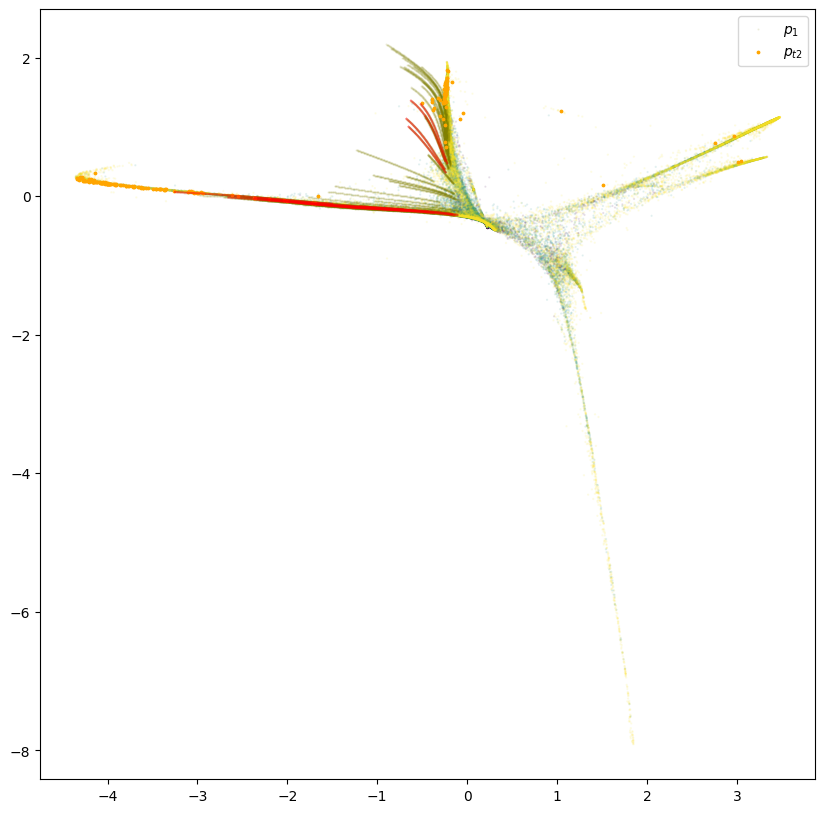

In [75]:
which_dim = [0,2]
fig, ax = plot_allcells_and_trajectories(traj_1_2.cpu().numpy(), which_dim=which_dim)
# ax.scatter(test_X[0][:,0], test_X[0][:,1], s=6, label=r'$p_{t0}$')
# ax.scatter(test_X[1][:,0], test_X[1][:,1], s=6, label=r'$p_{t1}$')
ax.scatter(test_X[2][:,which_dim[0]], test_X[2][:,which_dim[1]], s=3, label=r'$p_{t2}$', c='orange')
plt.legend()
fig.show()

# TrajectoryNet

In [56]:
from TrajectoryNet.parse import parser
from TrajectoryNet import dataset
from TrajectoryNet.train_misc import create_regularization_fns, build_model_tabular

In [54]:
DM_args =[
    "--dataset", "data/klein_for_TJN.npz",
    "--embedding_name", "DM",
    "--max_dim", "5",
    "--niters", "3000",
    "--save", "logs/TrajectoryNet/DM_multiscaled_with_growth",
    "--growth_path", "logs/TrajectoryNet/klein_TJN_growth_model.pt",
    "--use_growth"
            ]
            
            
args = parser.parse_args(
    DM_args
)

In [52]:
device = 'cuda:0'
ckpt = torch.load(f"{args.save}/checkpt-3000.pth")

In [57]:
data = dataset.SCData.factory(args.dataset, args)

timepoints = data.get_unique_times()

No velocity found for embedding DM skipping velocity


In [60]:
overlapped_cb_index

NameError: name 'overlapped_cb_index' is not defined

In [ ]:
X_test_ay = data.data[overlapped_cb_index]
X_test_ay = X_test_ay[:,0,:]

X_test = torch.tensor(X_test_ay).float().to(device)

In [ ]:
integration_times = torch.tensor([1.0, 3.5]).float()
z, delta_logp = cnf_net(X_test, zero, integration_times=integration_times, reverse=True)

with torch.no_grad():

    zs = [X_test] 
    # zs = [torch.tensor(X_last).to(device).float()]
    deltas = []
    int_tps = np.linspace(0.5, 3.0, 101)

    zero = torch.zeros((zs[0].shape[0],1)).type(torch.float32).to(device)

    for i, itp in enumerate(int_tps[1:]):
    # for i, itp in enumerate(int_tps[::-1][:-1]):
        # tp counts down from last
        timescale = int_tps[1] - int_tps[0]
        integration_times = torch.tensor([itp - timescale, itp])
        # integration_times = torch.tensor([np.linspace(itp - args.time_scale, itp, ntimes)])
        integration_times = integration_times.type(torch.float32).to(device)

        # transform to previous timepoint
        z, delta_logp = cnf_net(zs[-1], zero, integration_times=integration_times, reverse=True)
        zs.append(z)
        deltas.append(delta_logp)

        if i%10 == 0:
            print(integration_times)

    zs = torch.stack(zs, 0).cpu().numpy()

In [ ]:
regularization_fns, regularization_coeffs = create_regularization_fns(args)

# learn UMAP_transform

In [11]:
## KNN regressor

In [12]:
from sklearn import neighbors

NameError: name 'init_pos' is not defined

In [28]:
cb_train = np.random.choice(adata.obs_names, 40000)
cb_test = [cb for cb in adata.obs_names if cb not in cb_train]

In [33]:
X_train = adata[cb_train].obsm[cellstate_key]
X_test = adata[cb_test].obsm[cellstate_key]

y_train = adata[cb_train].obsm['X_umap']
y_test = adata[cb_test].obsm['X_umap']

In [46]:
n_neighbors = 15
weights = 'distance' # "distance"
knn = neighbors.KNeighborsRegressor(n_neighbors, weights=weights)
y_ = knn.fit(X_train, y_train).predict(X_test)

In [47]:
y_all = knn.predict(adata.obsm[cellstate_key])

In [40]:
X_umap = adata.obsm['X_umap']

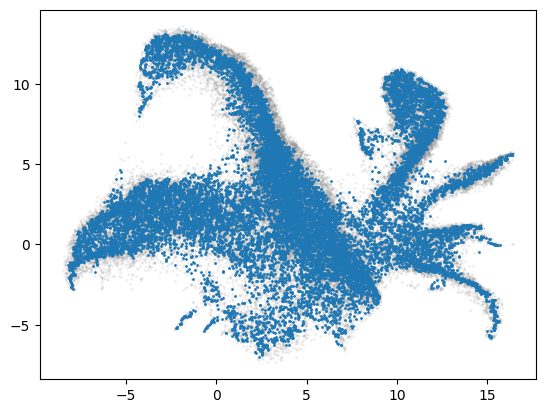

In [49]:
plt.scatter(X_umap[:,0], X_umap[:,1], s=1, color='gray', alpha=0.1)
# plt.scatter(y_all[:,0], y_all[:,1], s=1)
plt.scatter(y_[:,0], y_[:,1], s=1)